<a href="https://colab.research.google.com/github/nicole062797-star/TFM-fin-de-master-Ciencia-de-datos/blob/main/Modelos_Predictivos_Recaudacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Montamos el drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Importamos la libreria
import pandas as pd

In [5]:
ruta = "/content/drive/MyDrive/TFM/dataset_con_tasas.csv"
df = pd.read_csv(ruta)

/tmp/ipykernel_1716/506646508.py:2: DtypeWarning: Columns (1,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


In [6]:
#Importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [7]:
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.filters.hp_filter import hpfilter

In [8]:
#Primero instlamos luego importamos (Prophet puede no estar instalado en algunos entornos de Colab, por eso se instala antes de importarlo)
!pip install prophet -q
from prophet import Prophet

In [9]:
#configuración visual similar al notebook anterior
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [10]:
#usamos esta xarpeta de salida utilizada en el notebook anterior
OUTPUT_DIR = "/content/drive/MyDrive/TFM"

En esta fase se transforma la base de datos transaccional en una serie temporal mensual. El objetivo es analizar la evolución histórica de la recaudación emitida, identificar tendencia, estacionalidad y residuo, y construir modelos de forecasting que permitan proyectar la recaudación futura bajo la nueva política municipal.

In [11]:
#contruccion de la serie temporal
columnas_series = [
    {
        "anio": 2023,
        "fecha": "fecha_de_emision_2023",
        "valor": "valor_de_predio_emitido_2023"
    },
    {
        "anio": 2024,
        "fecha": "fecha_de_emision_2024",
        "valor": "valor_de_predio_emitido_2024"
    },
    {
        "anio": 2025,
        "fecha": "fecha_de_emision_2025",
        "valor": "valor_de_predio_emitido_2025"
    }
]

lista_series = []

for item in columnas_series:
    temp = df[[item["fecha"], item["valor"]]].copy()
    temp.columns = ["fecha", "valor_emitido"]
    temp["anio"] = item["anio"]

    #Conversión de tipos
    temp["fecha"] = pd.to_datetime(temp["fecha"], errors="coerce")
    temp["valor_emitido"] = pd.to_numeric(temp["valor_emitido"], errors="coerce")

    #Se eliminan registros sin fecha o sin valor emitido
    temp = temp.dropna(subset=["fecha", "valor_emitido"])

    lista_series.append(temp)

df_temporal = pd.concat(lista_series, ignore_index=True)

print("Dimensiones de la base temporal:", df_temporal.shape)
df_temporal.head()

Dimensiones de la base temporal: (145189, 3)


,fecha,valor_emitido,anio
0,2023-10-03,11.25,2023
1,2023-01-11,124.25,2023
2,2023-10-04,11.25,2023
3,2023-12-31,24.56,2023
4,2023-12-31,12.95,2023


En el dataset original, los valores de emisión se encuentran organizados por año en columnas separadas. Para construir una serie temporal se reorganizan los datos en formato largo, unificando fecha y valor emitido en una misma estructura.


In [12]:
#utilizamos los años previos como base histórica y proyectar el comportamiento desde 2026.
df_temporal = df_temporal[
    (df_temporal["fecha"] >= "2023-01-01") &
    (df_temporal["fecha"] <= "2025-12-31")
].copy()

In [13]:
df_temporal = pd.concat(lista_series, ignore_index=True)

print("Dimensiones de la base temporal antes del filtro:", df_temporal.shape)
df_temporal.head()

Dimensiones de la base temporal antes del filtro: (145189, 3)


,fecha,valor_emitido,anio
0,2023-10-03,11.25,2023
1,2023-01-11,124.25,2023
2,2023-10-04,11.25,2023
3,2023-12-31,24.56,2023
4,2023-12-31,12.95,2023


In [14]:
df_temporal = df_temporal[
    (df_temporal["fecha"] >= "2023-01-01") &
    (df_temporal["fecha"] <= "2025-12-31")
].copy()

print("Dimensiones de la base temporal después del filtro:", df_temporal.shape)
print("Fecha mínima:", df_temporal["fecha"].min())
print("Fecha máxima:", df_temporal["fecha"].max())

Dimensiones de la base temporal después del filtro: (145086, 3)
Fecha mínima: 2023-01-01 00:00:00
Fecha máxima: 2025-12-31 00:00:00


In [15]:
#agregación mensual de la recaudación emitida
df_temporal["mes"] = df_temporal["fecha"].dt.to_period("M").dt.to_timestamp()

serie_mensual_df = (
    df_temporal
    .groupby("mes")["valor_emitido"]
    .sum()
    .reset_index()
    .sort_values("mes")
)

serie_mensual = serie_mensual_df.set_index("mes")["valor_emitido"]

serie_mensual = serie_mensual.asfreq("MS").fillna(0)

print("Número de observaciones mensuales:", len(serie_mensual))
print("Fecha inicial:", serie_mensual.index.min())
print("Fecha final:", serie_mensual.index.max())

serie_mensual.head()

Número de observaciones mensuales: 36
Fecha inicial: 2023-01-01 00:00:00
Fecha final: 2025-12-01 00:00:00


,valor_emitido
mes,
2023-01-01,1023128.88
2023-02-01,3828.94
2023-03-01,15312.94
2023-04-01,6750.82
2023-05-01,21888.97


Se fuerza la frecuencia mensual al inicio de cada mes, si existieran meses sin registros, se rellenan con 0 porque representan ausencia de emisión registrada en ese periodo, no un error de lectura.

In [16]:
#guardamos la serie temporal mensual para trazabilidad del análisis
serie_mensual_export = serie_mensual.reset_index()
serie_mensual_export.columns = ["mes", "valor_emitido"]

serie_mensual_export.to_csv(
    f"{OUTPUT_DIR}/serie_mensual_recaudacion_emitida.csv",
    index=False
)

serie_mensual_export.head()

,mes,valor_emitido
0,2023-01-01,1023128.88
1,2023-02-01,3828.94
2,2023-03-01,15312.94
3,2023-04-01,6750.82
4,2023-05-01,21888.97


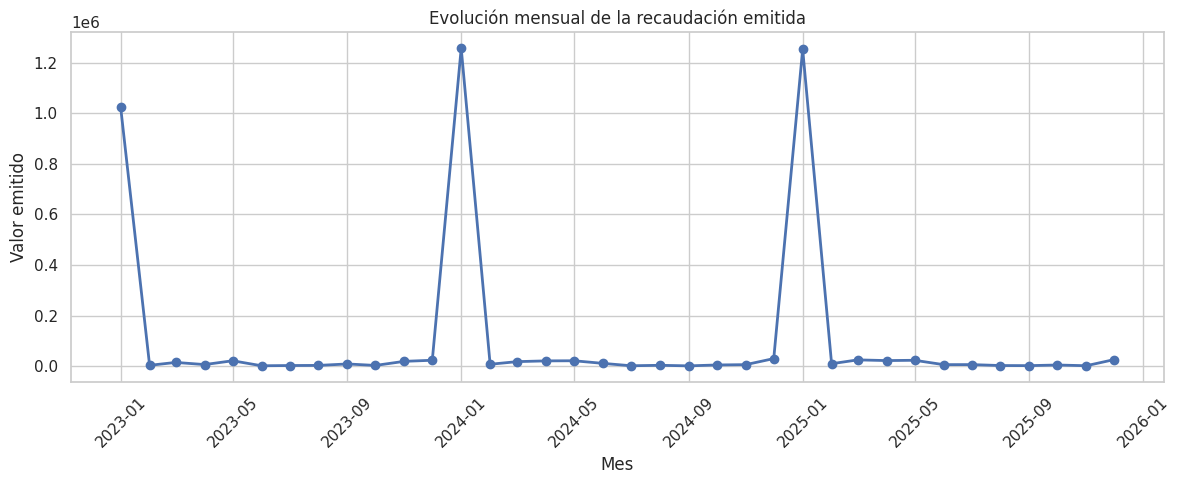

In [17]:
#Visualización exploratoria de la serie temporal
plt.figure(figsize=(12, 5))
plt.plot(
    serie_mensual.index,
    serie_mensual.values,
    marker="o",
    linewidth=2
)
plt.title("Evolución mensual de la recaudación emitida")
plt.xlabel("Mes")
plt.ylabel("Valor emitido")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_14_evolucion_mensual_recaudacion_emitida.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Este gráfico constituye el punto de partida para identificar tendencia, estacionalidad y variaciones atípicas en el comportamiento tributario municipal.

In [18]:
#Estadísticos descriptivos de la serie mensual
descripcion_serie = serie_mensual.describe().reset_index()
descripcion_serie.columns = ["Estadístico", "Valor"]

descripcion_serie.to_csv(
    f"{OUTPUT_DIR}/descripcion_serie_mensual_recaudacion.csv",
    index=False
)

descripcion_serie

,Estadístico,Valor
0,count,3.600000e+01
1,mean,1.086511e+05
2,std,3.285994e+05
3,min,1.711350e+03
4,25%,3.751585e+03
5,50%,8.622805e+03
6,75%,2.206099e+04
7,max,1.257203e+06


In [19]:
#Análisis mensual de estacionalidad
serie_estacionalidad = serie_mensual.reset_index()
serie_estacionalidad.columns = ["fecha", "valor_emitido"]
serie_estacionalidad["mes_num"] = serie_estacionalidad["fecha"].dt.month
serie_estacionalidad["mes_nombre"] = serie_estacionalidad["fecha"].dt.month_name()

estacionalidad_mensual = (
    serie_estacionalidad
    .groupby(["mes_num", "mes_nombre"])["valor_emitido"]
    .mean()
    .reset_index()
    .sort_values("mes_num")
)

estacionalidad_mensual.to_csv(
    f"{OUTPUT_DIR}/estacionalidad_promedio_mensual.csv",
    index=False
)

estacionalidad_mensual

,mes_num,mes_nombre,valor_emitido
0,1,January,1.177756e+06
1,2,February,7.327110e+03
2,3,March,1.969046e+04
3,4,April,1.690643e+04
4,5,May,2.249862e+04
5,6,June,6.714367e+03
6,7,July,3.950940e+03
7,8,August,3.479343e+03
8,9,September,4.517033e+03
9,10,October,4.565993e+03


Se calcula el promedio de recaudación emitida por mes calendario, este análisis permite identificar meses con mayor concentración de emisión, especialmente al inicio del año fiscal.


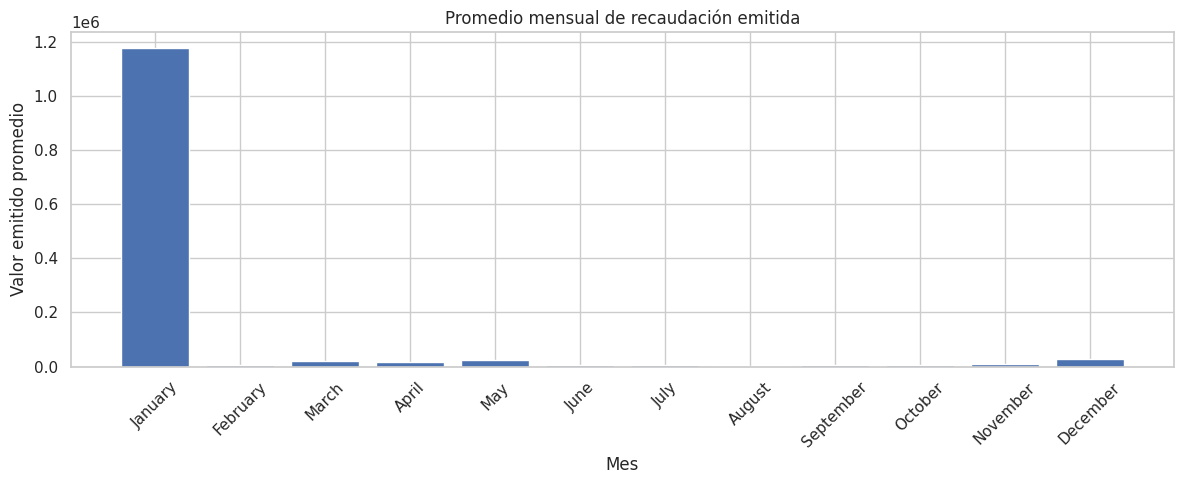

In [20]:
plt.figure(figsize=(12, 5))

plt.bar(
    estacionalidad_mensual["mes_nombre"],
    estacionalidad_mensual["valor_emitido"]
)

plt.title("Promedio mensual de recaudación emitida")
plt.xlabel("Mes")
plt.ylabel("Valor emitido promedio")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_17_promedio_mensual_recaudacion_emitida.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

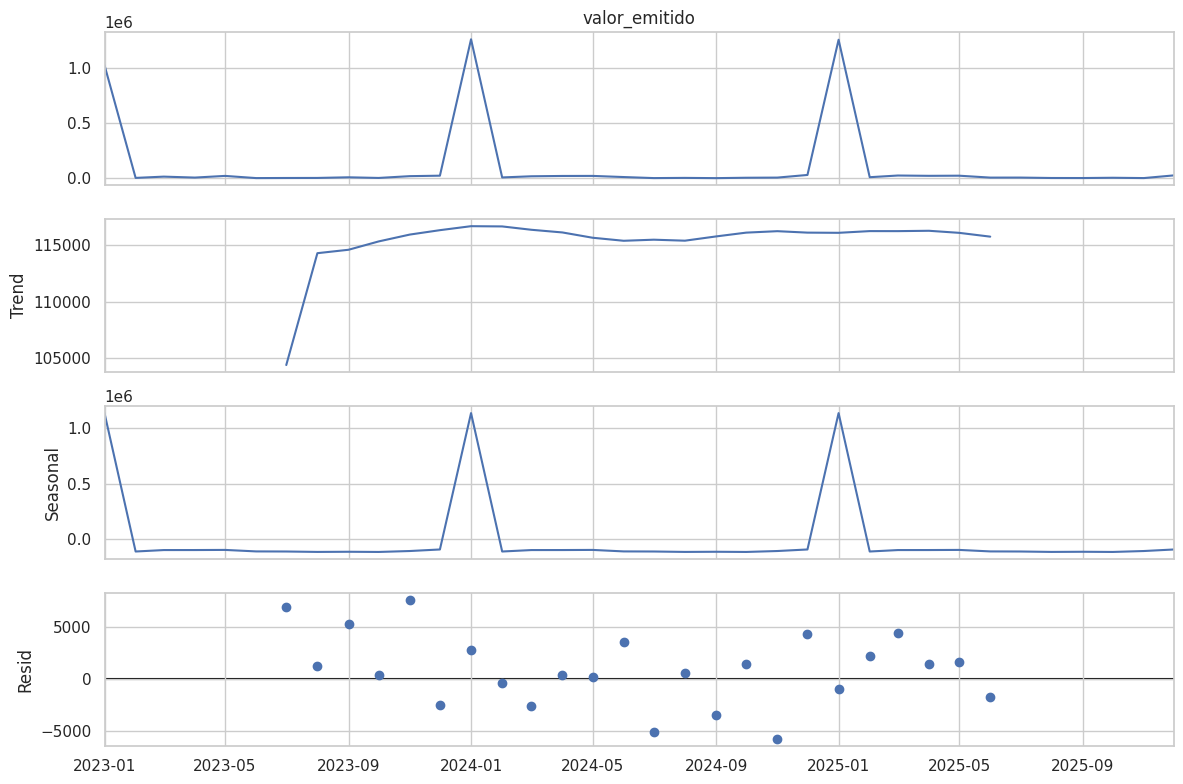

In [21]:
#Descomposición de la serie temporal
descomposicion = seasonal_decompose(
    serie_mensual,
    model="additive",
    period=12
)

fig = descomposicion.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_15_descomposicion_serie_temporal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La descomposición permite separar la serie en:
Tendencia: evolución estructural de largo plazo.
Estacionalidad: patrones que se repiten en periodos definidos.
Residuo: variación no explicada por tendencia ni estacionalidad.

Se utiliza un periodo de 12 meses para capturar estacionalidad anual, esto es coherente con una serie mensual de recaudación.

La descomposición de la serie temporal permite analizar por separado la tendencia, la estacionalidad y el residuo. Esto facilita identificar si los cambios observados responden a patrones estructurales, ciclos mensuales o fluctuaciones irregulares.

In [22]:
#Diagnóstico de estacionariedad y autocorrelación
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

adf_resultado = adfuller(serie_mensual)

tabla_adf = pd.DataFrame({
    "Indicador": [
        "ADF Statistic",
        "p-value",
        "Lags utilizados",
        "Número de observaciones"
    ],
    "Valor": [
        adf_resultado[0],
        adf_resultado[1],
        adf_resultado[2],
        adf_resultado[3]
    ]
})

tabla_adf.to_csv(
    f"{OUTPUT_DIR}/prueba_adf_estacionariedad.csv",
    index=False
)

tabla_adf

,Indicador,Valor
0,ADF Statistic,-30.489704
1,p-value,0.000000
2,Lags utilizados,10.000000
3,Número de observaciones,25.000000


En modelos ARIMA y SARIMA es importante analizar si la serie presenta estacionariedad. Para ello se aplica la prueba aumentada de Dickey-Fuller.
La hipótesis nula de esta prueba indica que la serie tiene raíz unitaria, es decir, no es estacionaria. Si el p-value es menor a 0.05, se rechaza la hipótesis nula y se considera que la serie es estacionaria.


In [23]:
#Análisis exploratorio previo al modelado de regresión
variables_modelo = [
    "valor_posesion_avaluo_patrimonio",
    "valor_de_predio_emitido_2023",
    "valor_de_predio_emitido_2024",
    "valor_de_predio_emitido_2025"
]

df_modelo_eda = df[variables_modelo].copy()

#Estadísticos descriptivos
estadisticos_regresion = df_modelo_eda.describe().T

estadisticos_regresion.to_csv(
    f"{OUTPUT_DIR}/tabla_estadisticos_variables_regresion.csv",
    index=True
)

estadisticos_regresion

,count,mean,std,min,25%,50%,75%,max
valor_posesion_avaluo_patrimonio,38231.0,21090.198263,56357.756029,0.0,2500.0000,7400.00,22488.625,4191604.37
valor_de_predio_emitido_2023,56350.0,20.299411,68.403199,0.0,2.3800,3.86,22.660,5870.38
valor_de_predio_emitido_2024,56350.0,24.599016,67.412819,0.0,10.0225,14.96,23.190,5459.32
valor_de_predio_emitido_2025,56350.0,24.555014,63.691905,0.0,13.2300,14.86,22.850,4969.17


Este bloque permite analizar las variables numéricas antes del entrenamiento
del modelo, con el fin de revisar estadísticos descriptivos y correlaciones entre las variables explicativas y la variable objetivo.



In [24]:
#Matriz de correlación de variables numéricas del modelo

matriz_correlacion = df_modelo_eda.corr()

matriz_correlacion.to_csv(
    f"{OUTPUT_DIR}/tabla_correlacion_variables_regresion.csv",
    index=True
)

matriz_correlacion

,valor_posesion_avaluo_patrimonio,valor_de_predio_emitido_2023,valor_de_predio_emitido_2024,valor_de_predio_emitido_2025
valor_posesion_avaluo_patrimonio,1.000000,0.135173,0.131850,0.143318
valor_de_predio_emitido_2023,0.135173,1.000000,0.859778,0.830865
valor_de_predio_emitido_2024,0.131850,0.859778,1.000000,0.866140
valor_de_predio_emitido_2025,0.143318,0.830865,0.866140,1.000000


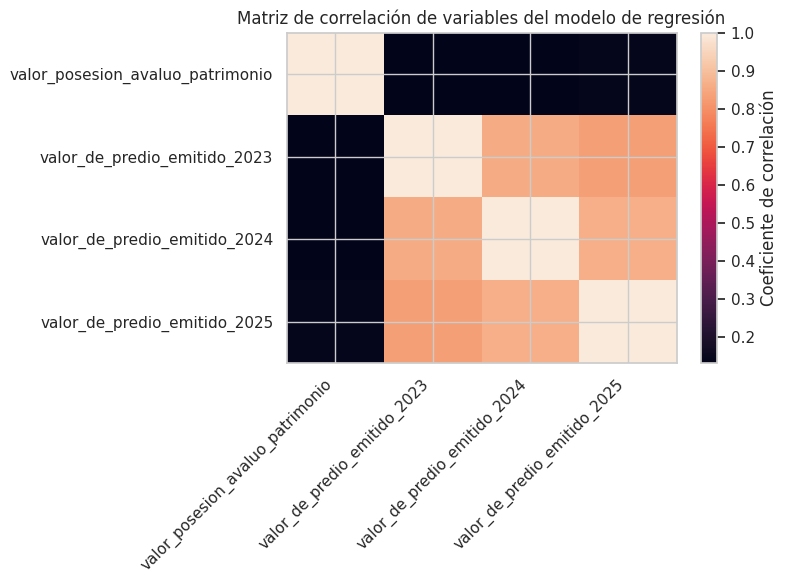

In [25]:
#Visualización de la matriz de correlación
plt.figure(figsize=(8, 6))
plt.imshow(matriz_correlacion, aspect="auto")
plt.colorbar(label="Coeficiente de correlación")

plt.xticks(
    range(len(matriz_correlacion.columns)),
    matriz_correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_correlacion.index)),
    matriz_correlacion.index
)

plt.title("Matriz de correlación de variables del modelo de regresión")
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_matriz_correlacion_regresion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

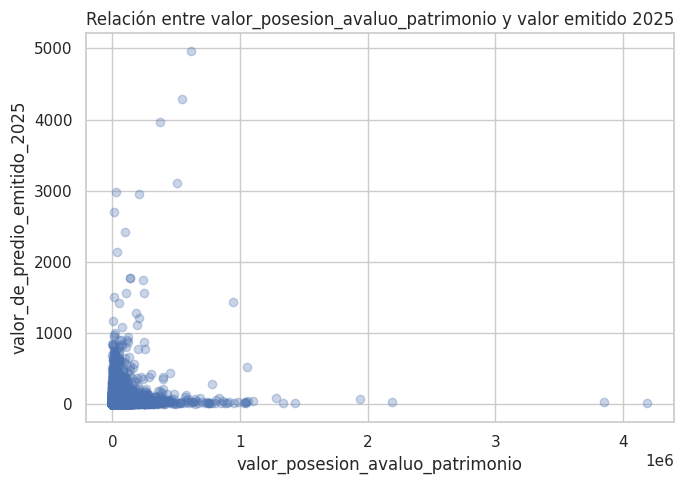

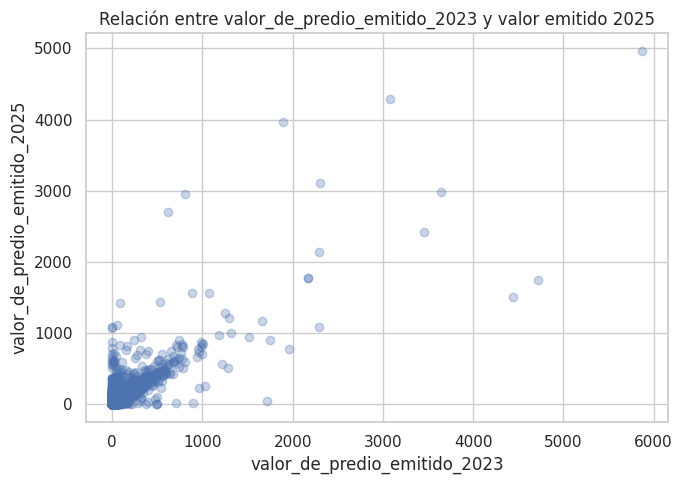

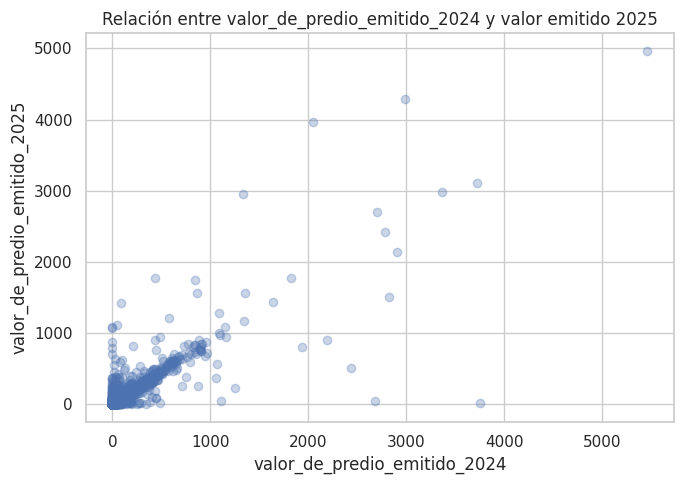

In [26]:
#Diagramas de dispersión entre predictores principales y variable objetivo
predictores_principales = [
    "valor_posesion_avaluo_patrimonio",
    "valor_de_predio_emitido_2023",
    "valor_de_predio_emitido_2024"
]

for variable in predictores_principales:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        df_modelo_eda[variable],
        df_modelo_eda["valor_de_predio_emitido_2025"],
        alpha=0.3
    )

    plt.title(f"Relación entre {variable} y valor emitido 2025")
    plt.xlabel(variable)
    plt.ylabel("valor_de_predio_emitido_2025")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/dispersion_{variable}_vs_emitido_2025.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

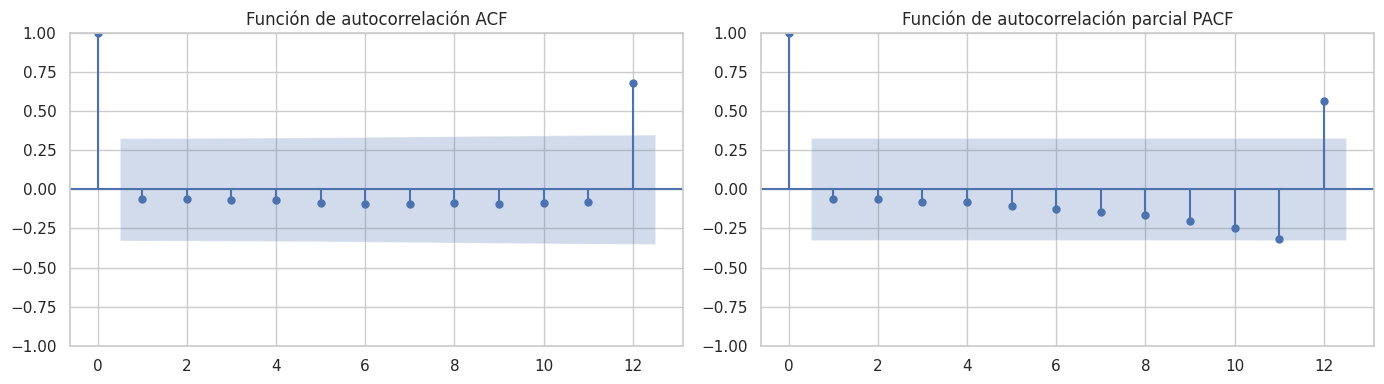

In [27]:
#Gráficos ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie_mensual, ax=axes[0], lags=min(12, len(serie_mensual)-1))
axes[0].set_title("Función de autocorrelación ACF")

plot_pacf(serie_mensual, ax=axes[1], lags=min(12, len(serie_mensual)//2 - 1))
axes[1].set_title("Función de autocorrelación parcial PACF")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_16_acf_pacf_serie_temporal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Estos gráficos permiten observar la autocorrelación de la serie con sus rezagos.
ACF ayuda a identificar dependencia temporal general.
PACF ayuda a identificar relaciones directas con rezagos específicos.

In [28]:
#División temporal entrenamiento/prueba
n_test = 6

train = serie_mensual.iloc[:-n_test]
test = serie_mensual.iloc[-n_test:]

print("Tamaño entrenamiento:", len(train))
print("Tamaño prueba:", len(test))
print("Periodo entrenamiento:", train.index.min(), "a", train.index.max())
print("Periodo prueba:", test.index.min(), "a", test.index.max())

Tamaño entrenamiento: 30
Tamaño prueba: 6
Periodo entrenamiento: 2023-01-01 00:00:00 a 2025-06-01 00:00:00
Periodo prueba: 2025-07-01 00:00:00 a 2025-12-01 00:00:00


En series temporales no se realiza una división aleatoria, ya que eso rompería el orden cronológico y generaría contaminación de información futura. Por ello, se utiliza la parte inicial de la serie para entrenamiento y los últimos meses como conjunto de prueba.

In [29]:
#Función auxiliar para calcular métricas de error
def calcular_metricas_forecasting(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    return mae, rmse

In [30]:
#modelo ARIMA
modelo_arima = ARIMA(train, order=(1, 1, 1))
resultado_arima = modelo_arima.fit()

pred_arima = resultado_arima.forecast(steps=len(test))
pred_arima.index = test.index

mae_arima, rmse_arima = calcular_metricas_forecasting(test, pred_arima)

print("Resultados ARIMA")
print("AIC:", resultado_arima.aic)
print("BIC:", resultado_arima.bic)
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)

Resultados ARIMA
AIC: 829.7359668711532
BIC: 833.8378543611126
MAE: 116583.04135654087
RMSE: 116904.80954137868


El modelo ARIMA captura la dinámica temporal de la serie mediante componentes autorregresivos, diferenciación e innovación del error. Se utiliza como modelo base para evaluar la capacidad predictiva de la serie sin componente estacional explícito.

In [31]:
#Modelo SARIMA
modelo_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo_sarima.fit(disp=False)

pred_sarima = resultado_sarima.forecast(steps=len(test))
pred_sarima.index = test.index

mae_sarima, rmse_sarima = calcular_metricas_forecasting(test, pred_sarima)

print("Resultados SARIMA")
print("AIC:", resultado_sarima.aic)
print("BIC:", resultado_sarima.bic)
print("MAE:", mae_sarima)
print("RMSE:", rmse_sarima)

Resultados SARIMA
AIC: 67.59368796529026
BIC: 63.086749408630816
MAE: 7670.856199605628
RMSE: 8278.20125689937


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


El modelo SARIMA amplía ARIMA incorporando una estructura estacional, se utiliza periodicidad 12 porque la serie tiene frecuencia mensual y se busca capturar posibles ciclos anuales de recaudación

In [32]:
#Modelo Prophet
df_prophet = serie_mensual.reset_index()
df_prophet.columns = ["ds", "y"]

train_prophet = df_prophet.iloc[:-n_test]
test_prophet = df_prophet.iloc[-n_test:]

modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

modelo_prophet.fit(train_prophet)

future_test = modelo_prophet.make_future_dataframe(
    periods=len(test),
    freq="MS"
)

forecast_test = modelo_prophet.predict(future_test)

pred_prophet = (
    forecast_test
    .tail(len(test))
    .set_index("ds")["yhat"]
)

pred_prophet.index = test.index

mae_prophet, rmse_prophet = calcular_metricas_forecasting(test, pred_prophet)

print("Resultados Prophet")
print("MAE:", mae_prophet)
print("RMSE:", rmse_prophet)

INFO:prophet:n_changepoints greater than number of observations. Using 23.


Resultados Prophet
MAE: 3388.0675088769462
RMSE: 3601.930056646114


Prophet requiere que la serie tenga dos columnas:
ds: fecha
y: valor de la serie
Este modelo es útil para capturar tendencia, estacionalidad e intervalos de incertidumbre.



In [33]:
#Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [34]:
#Importancia de variables del modelo Random Forest optimizado
df_modelo_eda_cleaned = df_modelo_eda.dropna()

X = df_modelo_eda_cleaned[
    [
        "valor_posesion_avaluo_patrimonio",
        "valor_de_predio_emitido_2023",
        "valor_de_predio_emitido_2024"
    ]
]

y = df_modelo_eda_cleaned["valor_de_predio_emitido_2025"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

modelo_rf_optimizado = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42
)

modelo_rf_optimizado.fit(X_train, y_train)

importancias = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": modelo_rf_optimizado.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias.to_csv(
    f"{OUTPUT_DIR}/tabla_importancia_variables_random_forest.csv",
    index=False
)

importancias

,variable,importancia
2,valor_de_predio_emitido_2024,0.706999
1,valor_de_predio_emitido_2023,0.220994
0,valor_posesion_avaluo_patrimonio,0.072006


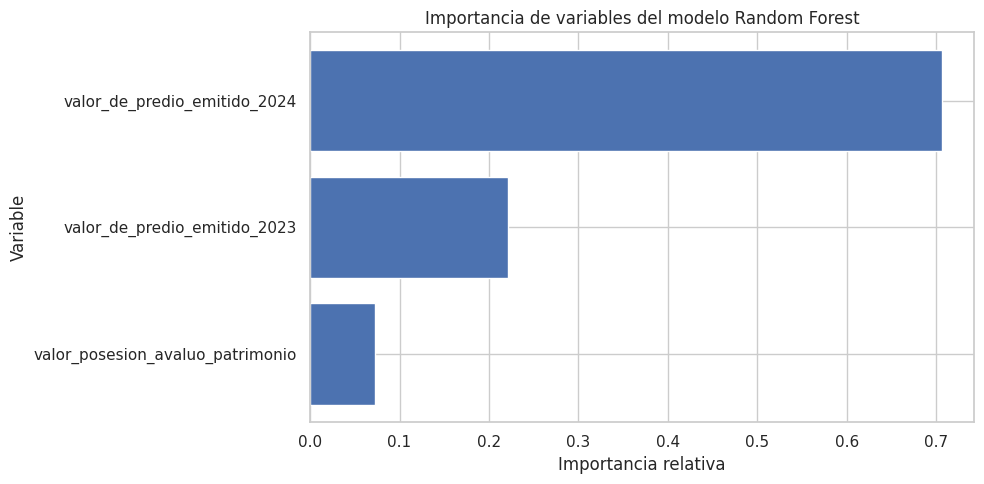

In [35]:
#Visualización de la importancia de variables
plt.figure(figsize=(10, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"]
)

plt.gca().invert_yaxis()
plt.title("Importancia de variables del modelo Random Forest")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_importancia_variables_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

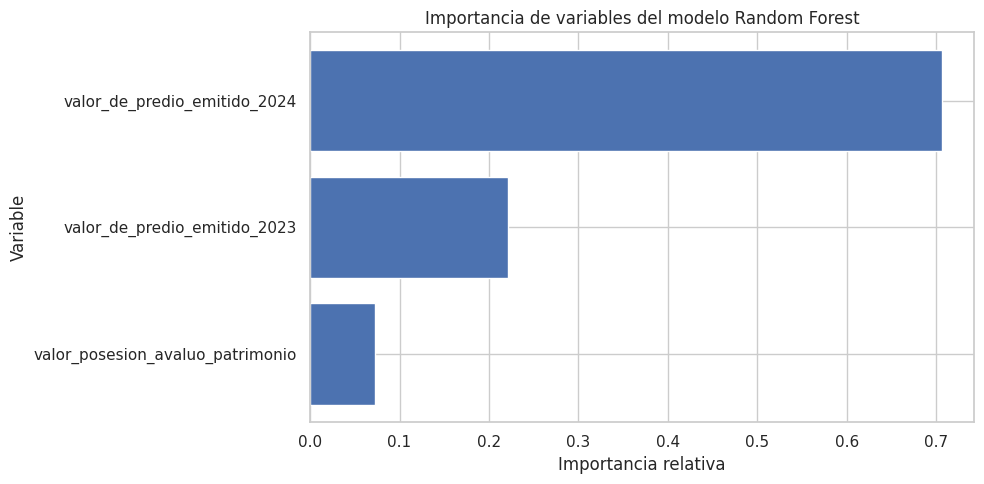

In [36]:
#visualización de la importancia de variables

plt.figure(figsize=(10, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"]
)

plt.gca().invert_yaxis()
plt.title("Importancia de variables del modelo Random Forest")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_importancia_variables_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [38]:
#Modelo línea base: predice siempre la media del conjunto de entrenamiento
modelo_dummy = DummyRegressor(strategy="mean")
modelo_dummy.fit(X_train, y_train)

pred_dummy = modelo_dummy.predict(X_test)

mae_dummy = mean_absolute_error(y_test, pred_dummy)
mse_dummy = mean_squared_error(y_test, pred_dummy)
rmse_dummy = np.sqrt(mse_dummy)
r2_dummy = r2_score(y_test, pred_dummy)

print("Resultados Dummy Regressor")
print("MAE:", mae_dummy)
print("MSE:", mse_dummy)
print("RMSE:", rmse_dummy)
print("R2:", r2_dummy)

Resultados Dummy Regressor
MAE: 22.605362333651488
MSE: 5934.3252915892535
RMSE: 77.03457205430075
R2: -0.00010427161009718411


In [39]:
#Comparación de modelos
comparacion_series = pd.DataFrame({
    "Modelo": ["ARIMA", "SARIMA", "Prophet"],
    "MAE": [mae_arima, mae_sarima, mae_prophet],
    "RMSE": [rmse_arima, rmse_sarima, rmse_prophet],
    "AIC": [resultado_arima.aic, resultado_sarima.aic, np.nan],
    "BIC": [resultado_arima.bic, resultado_sarima.bic, np.nan]
})

comparacion_series_ordenada = comparacion_series.sort_values(by="RMSE")

comparacion_series_ordenada.to_csv(
    f"{OUTPUT_DIR}/tabla_11_comparacion_modelos_series_temporales.csv",
    index=False
)

comparacion_series_ordenada

,Modelo,MAE,RMSE,AIC,BIC
2,Prophet,3388.067509,3601.930057,NaN,NaN
1,SARIMA,7670.856200,8278.201257,67.593688,63.086749
0,ARIMA,116583.041357,116904.809541,829.735967,833.837854


La comparación se realiza mediante métricas de error predictivo. Para ARIMA y SARIMA se incluyen también AIC y BIC, criterios de información que penalizan la complejidad del modelo. Prophet no reporta AIC/BIC de forma directa, por lo que se compara mediante MAE y RMSE.


In [40]:
#Exportación de predicciones sobre conjunto de prueba
predicciones_test_series = pd.DataFrame({
    "fecha": test.index,
    "valor_real": test.values,
    "prediccion_arima": pred_arima.values,
    "prediccion_sarima": pred_sarima.values,
    "prediccion_prophet": pred_prophet.values
})

predicciones_test_series.to_csv(
    f"{OUTPUT_DIR}/predicciones_test_modelos_series_temporales.csv",
    index=False
)

predicciones_test_series

,fecha,valor_real,prediccion_arima,prediccion_sarima,prediccion_prophet
0,2025-07-01,6703.03,126207.147757,384.009592,9706.309108
1,2025-08-01,2985.97,123865.006826,-7504.661233,7463.432165
2,2025-09-01,2597.10,123910.842449,-6509.971515,4313.781899
3,2025-10-01,5085.77,123909.945447,-4230.548236,1170.339463
4,2025-11-01,2261.59,123909.963001,-7210.064036,4374.982133
5,2025-12-01,26581.16,123909.962658,25260.718231,21479.000789


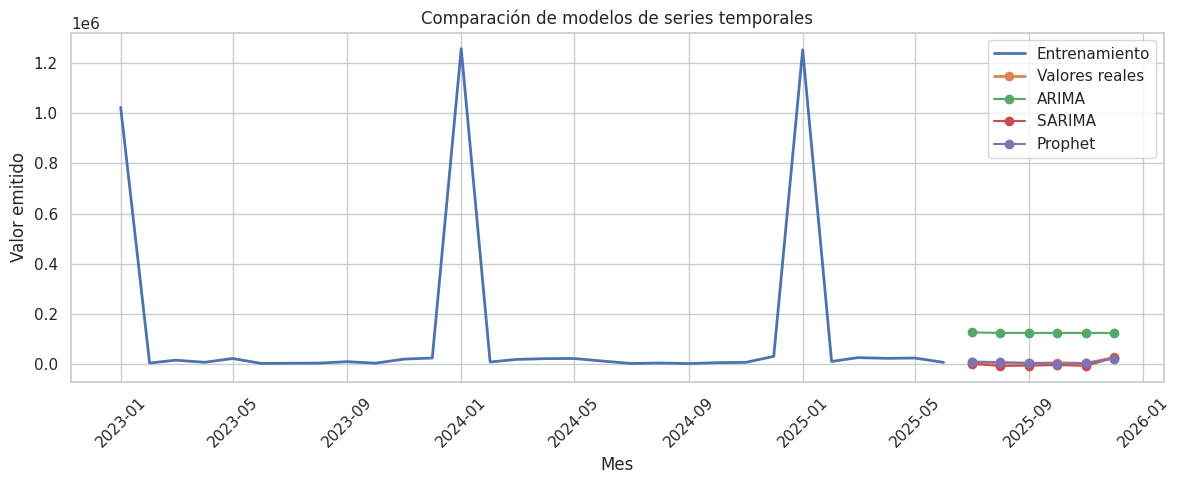

In [41]:
#Gráfico comparativo entre valores reales y predicciones de cada modelo
plt.figure(figsize=(12, 5))

plt.plot(train.index, train.values, label="Entrenamiento", linewidth=2)
plt.plot(test.index, test.values, label="Valores reales", marker="o", linewidth=2)
plt.plot(test.index, pred_arima.values, label="ARIMA", marker="o")
plt.plot(test.index, pred_sarima.values, label="SARIMA", marker="o")
plt.plot(test.index, pred_prophet.values, label="Prophet", marker="o")

plt.title("Comparación de modelos de series temporales")
plt.xlabel("Mes")
plt.ylabel("Valor emitido")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_16_comparacion_modelos_series_temporales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La comparación visual permite evaluar el grado de ajuste de cada modelo frente a los valores reales del conjunto de prueba. Esta evaluación se complementa con métricas cuantitativas como MAE, RMSE, AIC y BIC.

In [42]:
#Selección automática del modelo con menor RMSE
mejor_modelo_series = comparacion_series_ordenada.iloc[0]["Modelo"]
print("Mejor modelo según RMSE:", mejor_modelo_series)

Mejor modelo según RMSE: Prophet


In [43]:
#Proyección futura con el modelo seleccionado
horizonte = 60

if mejor_modelo_series == "ARIMA":

    modelo_final_series = ARIMA(serie_mensual, order=(1, 1, 1)).fit()
    forecast_futuro = modelo_final_series.get_forecast(steps=horizonte)

    pred_futura = forecast_futuro.predicted_mean
    intervalo_futuro = forecast_futuro.conf_int()

elif mejor_modelo_series == "SARIMA":

    modelo_final_series = SARIMAX(
        serie_mensual,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    forecast_futuro = modelo_final_series.get_forecast(steps=horizonte)

    pred_futura = forecast_futuro.predicted_mean
    intervalo_futuro = forecast_futuro.conf_int()

else:

    modelo_final_series = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    modelo_final_series.fit(df_prophet)

    future = modelo_final_series.make_future_dataframe(
        periods=horizonte,
        freq="MS"
    )

    forecast_futuro_prophet = modelo_final_series.predict(future)

    futuro = forecast_futuro_prophet.tail(horizonte)

    pred_futura = futuro.set_index("ds")["yhat"]
    intervalo_futuro = futuro.set_index("ds")[["yhat_lower", "yhat_upper"]]

proyeccion_futura = pd.DataFrame({
    "fecha": pred_futura.index,
    "recaudacion_proyectada": pred_futura.values
})

proyeccion_futura.to_csv(
    f"{OUTPUT_DIR}/proyeccion_recaudacion_2026_2030.csv",
    index=False
)

proyeccion_futura.head()

,fecha,recaudacion_proyectada
0,2026-01-01,1.203183e+06
1,2026-02-01,2.234236e+04
2,2026-03-01,3.804442e+04
3,2026-04-01,2.663810e+04
4,2026-05-01,3.035734e+04


Se proyectan 60 meses futuros, correspondientes aproximadamente al periodo 2026-2030, esta proyección sirve como base para construir los escenarios financieros posteriores.



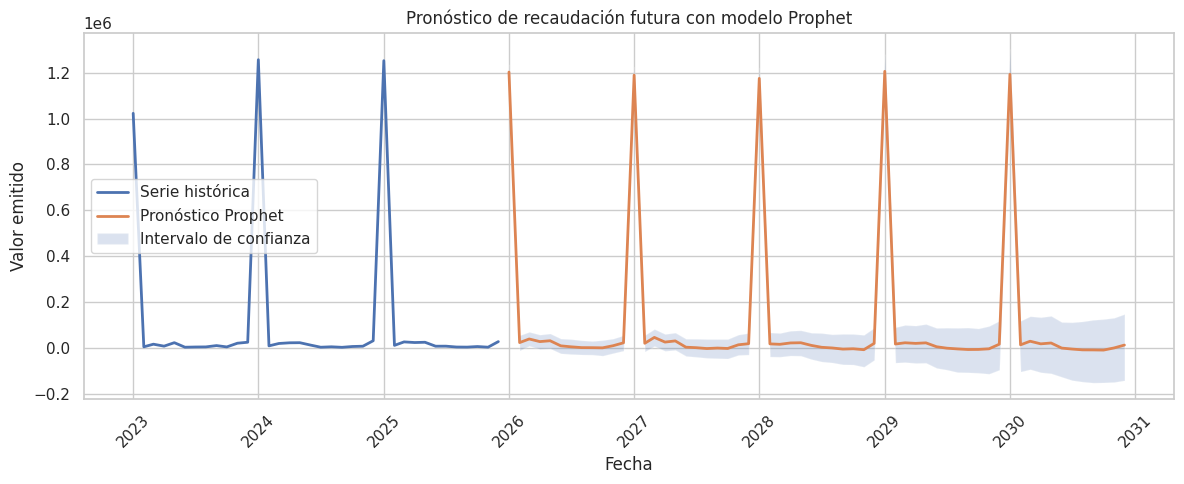

In [44]:
#Visualización del pronóstico futuro
plt.figure(figsize=(12, 5))
plt.plot(
    serie_mensual.index,
    serie_mensual.values,
    label="Serie histórica",
    linewidth=2
)

plt.plot(
    pred_futura.index,
    pred_futura.values,
    label=f"Pronóstico {mejor_modelo_series}",
    linewidth=2
)

if mejor_modelo_series in ["ARIMA", "SARIMA"]:
    plt.fill_between(
        pred_futura.index,
        intervalo_futuro.iloc[:, 0],
        intervalo_futuro.iloc[:, 1],
        alpha=0.2,
        label="Intervalo de confianza"
    )
else:
    plt.fill_between(
        pred_futura.index,
        intervalo_futuro["yhat_lower"],
        intervalo_futuro["yhat_upper"],
        alpha=0.2,
        label="Intervalo de confianza"
    )

plt.title(f"Pronóstico de recaudación futura con modelo {mejor_modelo_series}")
plt.xlabel("Fecha")
plt.ylabel("Valor emitido")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_17_pronostico_recaudacion_futura.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El pronóstico futuro permite estimar el comportamiento esperado de la recaudación bajo la dinámica histórica observada. Los intervalos de confianza representan la incertidumbre asociada a la proyección.

In [45]:
#Construcción de escenarios financieros
escenarios = pd.DataFrame({
    "fecha": pred_futura.index,
    "proyeccion_base": pred_futura.values
})

escenarios["escenario_pesimista_30"] = escenarios["proyeccion_base"] * 0.30
escenarios["escenario_moderado_70"] = escenarios["proyeccion_base"] * 0.70
escenarios["escenario_optimo_100"] = escenarios["proyeccion_base"] * 1.00

escenarios["anio"] = escenarios["fecha"].dt.year

resumen_escenarios_anual = (
    escenarios
    .groupby("anio")[
        [
            "escenario_pesimista_30",
            "escenario_moderado_70",
            "escenario_optimo_100"
        ]
    ]
    .sum()
    .reset_index()
)

escenarios.to_csv(
    f"{OUTPUT_DIR}/escenarios_mensuales_recaudacion_2026_2030.csv",
    index=False
)

resumen_escenarios_anual.to_csv(
    f"{OUTPUT_DIR}/tabla_12_escenarios_financieros_anuales.csv",
    index=False
)

resumen_escenarios_anual

,anio,escenario_pesimista_30,escenario_moderado_70,escenario_optimo_100
0,2026,408773.879036,953805.717751,1.362580e+06
1,2027,399569.845764,932329.640115,1.331899e+06
2,2028,377874.523599,881707.221732,1.259582e+06
3,2029,382690.991470,892945.646764,1.275637e+06
4,2030,373523.131421,871553.973317,1.245077e+06


A partir de la proyección base se construyen tres escenarios de cumplimiento:
Pesimista: 30%
Moderado: 70%
Óptimo: 100%
Estos escenarios permiten evaluar la brecha financiera potencial para el municipio.


In [46]:
#Se limita el análisis de escenarios al periodo 2026-2030
escenarios = escenarios[
    (escenarios["fecha"] >= "2026-01-01") &
    (escenarios["fecha"] <= "2030-12-31")
].copy()

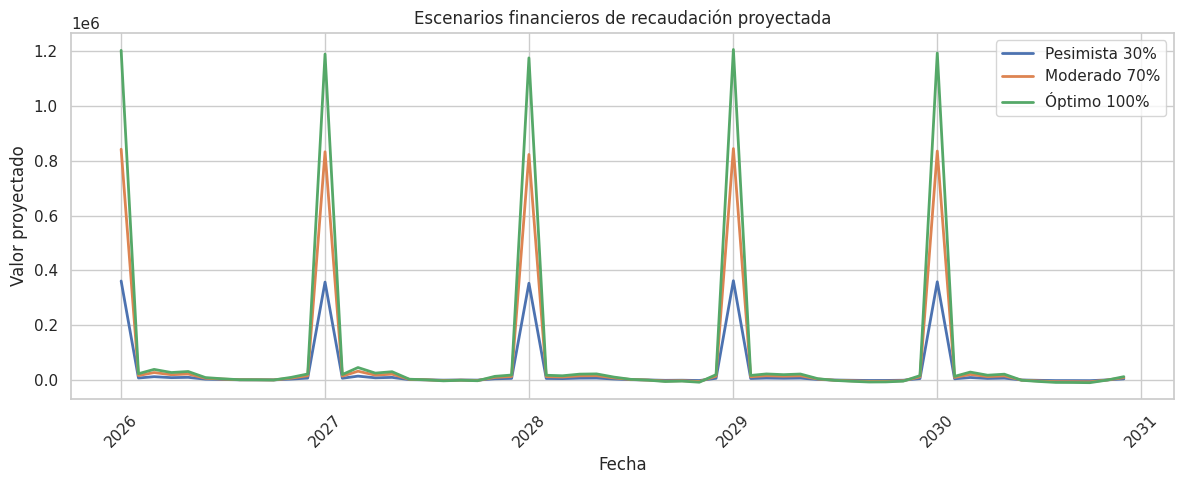

In [47]:
#Gráfico de escenarios financieros
plt.figure(figsize=(12, 5))

plt.plot(
    escenarios["fecha"],
    escenarios["escenario_pesimista_30"],
    label="Pesimista 30%",
    linewidth=2
)

plt.plot(
    escenarios["fecha"],
    escenarios["escenario_moderado_70"],
    label="Moderado 70%",
    linewidth=2
)

plt.plot(
    escenarios["fecha"],
    escenarios["escenario_optimo_100"],
    label="Óptimo 100%",
    linewidth=2
)

plt.title("Escenarios financieros de recaudación proyectada")
plt.xlabel("Fecha")
plt.ylabel("Valor proyectado")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_18_escenarios_financieros_recaudacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Los escenarios financieros permiten evaluar el impacto de distintos niveles de cumplimiento ciudadano sobre la recaudación futura. Esta simulación es útil para la planificación presupuestaria y la evaluación de sostenibilidad del servicio.

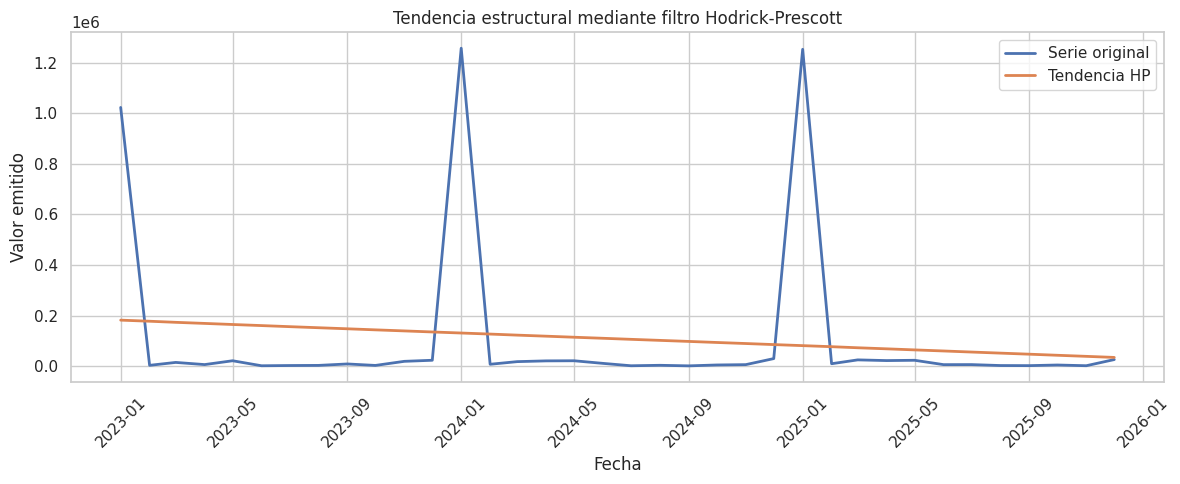

In [48]:
#Filtro Hodrick-Prescott
ciclo_hp, tendencia_hp = hpfilter(
    serie_mensual,
    lamb=129600
)

tendencia_hp_df = pd.DataFrame({
    "fecha": tendencia_hp.index,
    "serie_original": serie_mensual.values,
    "tendencia_hp": tendencia_hp.values,
    "ciclo_hp": ciclo_hp.values
})

tendencia_hp_df.to_csv(
    f"{OUTPUT_DIR}/tendencia_hodrick_prescott.csv",
    index=False
)

plt.figure(figsize=(12, 5))

plt.plot(
    serie_mensual.index,
    serie_mensual.values,
    label="Serie original",
    linewidth=2
)

plt.plot(
    tendencia_hp.index,
    tendencia_hp.values,
    label="Tendencia HP",
    linewidth=2
)

plt.title("Tendencia estructural mediante filtro Hodrick-Prescott")
plt.xlabel("Fecha")
plt.ylabel("Valor emitido")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_19_tendencia_hodrick_prescott.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El filtro Hodrick-Prescott permite separar la tendencia estructural de la serie
respecto a su componente cíclico. Para datos mensuales se utiliza comúnmente lambda = 129600.

0Permite aislar la tendencia estructural de la recaudación, suavizando las fluctuaciones de corto plazo. Esto facilita interpretar la trayectoria subyacente de los ingresos municipales.

In [49]:
#Verificación de archivos generados
print("Archivos principales generados en:", OUTPUT_DIR)
print("- serie_mensual_recaudacion_emitida.csv")
print("- descripcion_serie_mensual_recaudacion.csv")
print("- tabla_11_comparacion_modelos_series_temporales.csv")
print("- proyeccion_recaudacion_2026_2030.csv")
print("- escenarios_mensuales_recaudacion_2026_2030.csv")
print("- tabla_12_escenarios_financieros_anuales.csv")
print("- tendencia_hodrick_prescott.csv")
print("- ilustracion_14_evolucion_mensual_recaudacion_emitida.png")
print("- ilustracion_15_descomposicion_serie_temporal.png")
print("- ilustracion_16_comparacion_modelos_series_temporales.png")
print("- ilustracion_17_pronostico_recaudacion_futura.png")
print("- ilustracion_18_escenarios_financieros_recaudacion.png")
print("- ilustracion_19_tendencia_hodrick_prescott.png")

Archivos principales generados en: /content/drive/MyDrive/TFM
- serie_mensual_recaudacion_emitida.csv
- descripcion_serie_mensual_recaudacion.csv
- tabla_11_comparacion_modelos_series_temporales.csv
- proyeccion_recaudacion_2026_2030.csv
- escenarios_mensuales_recaudacion_2026_2030.csv
- tabla_12_escenarios_financieros_anuales.csv
- tendencia_hodrick_prescott.csv
- ilustracion_14_evolucion_mensual_recaudacion_emitida.png
- ilustracion_15_descomposicion_serie_temporal.png
- ilustracion_16_comparacion_modelos_series_temporales.png
- ilustracion_17_pronostico_recaudacion_futura.png
- ilustracion_18_escenarios_financieros_recaudacion.png
- ilustracion_19_tendencia_hodrick_prescott.png


In [50]:
#Carga de resultados
predicciones_regresion = pd.read_csv(
    f"{OUTPUT_DIR}/predicciones_regresion_2025.csv"
)

proyeccion_temporal = pd.read_csv(
    f"{OUTPUT_DIR}/proyeccion_recaudacion_2026_2030.csv"
)

estacionalidad_mensual = pd.read_csv(
    f"{OUTPUT_DIR}/estacionalidad_promedio_mensual.csv"
)

proyeccion_temporal["fecha"] = pd.to_datetime(proyeccion_temporal["fecha"])
proyeccion_temporal["anio"] = proyeccion_temporal["fecha"].dt.year
proyeccion_temporal["mes_num"] = proyeccion_temporal["fecha"].dt.month

print("Predicciones regresión:", predicciones_regresion.shape)
print("Proyección temporal:", proyeccion_temporal.shape)
print("Estacionalidad mensual:", estacionalidad_mensual.shape)

Predicciones regresión: (11270, 3)
Proyección temporal: (60, 4)
Estacionalidad mensual: (12, 3)


en esta fase se integran los resultados del modelo de regresión supervisada y del modelo de series temporales. La regresión aporta una estimación del valor esperado de recaudación a nivel de observación, mientras que la serie temporal permite distribuir dicha recaudación según el patrón mensual observado.


In [51]:
#Cálculo del factor mensual de estacionalidad
estacionalidad_mensual["factor_estacional"] = (
    estacionalidad_mensual["valor_emitido"] /
    estacionalidad_mensual["valor_emitido"].sum()
)

estacionalidad_mensual[["mes_num", "mes_nombre", "valor_emitido", "factor_estacional"]]

,mes_num,mes_nombre,valor_emitido,factor_estacional
0,1,January,1.177756e+06,0.903317
1,2,February,7.327110e+03,0.005620
2,3,March,1.969046e+04,0.015102
3,4,April,1.690643e+04,0.012967
4,5,May,2.249862e+04,0.017256
5,6,June,6.714367e+03,0.005150
6,7,July,3.950940e+03,0.003030
7,8,August,3.479343e+03,0.002669
8,9,September,4.517033e+03,0.003464
9,10,October,4.565993e+03,0.003502


Se calcula el peso relativo de cada mes dentro del patrón anual promedio, Este factor representa la proporción esperada de recaudación que tiende concentrarse en cada mes según el comportamiento histórico 2023-2025.


In [52]:
#guardamos factores de estacionalidad para trazabilidad
estacionalidad_mensual.to_csv(
    f"{OUTPUT_DIR}/factores_estacionalidad_mensual.csv",
    index=False
)

In [53]:
#estimación agregada desde el modelo de regresión
recaudacion_base_regresion = predicciones_regresion["valor_predicho"].sum()

print("Recaudación base estimada por regresión:", recaudacion_base_regresion)

Recaudación base estimada por regresión: 272183.63015525986


Se utiliza la suma de valores predichos por el modelo de regresión como estimación agregada de recaudación base. Esta base se puede comparar con la proyección temporal obtenida mediante Prophet.


In [54]:
#Integración agregada: regresión + estacionalidad temporal
integracion_mensual = []

for anio in range(2026, 2031):
    for _, fila in estacionalidad_mensual.iterrows():
        integracion_mensual.append({
            "anio": anio,
            "mes_num": fila["mes_num"],
            "mes_nombre": fila["mes_nombre"],
            "factor_estacional": fila["factor_estacional"],
            "recaudacion_integrada": recaudacion_base_regresion * fila["factor_estacional"]
        })

integracion_mensual = pd.DataFrame(integracion_mensual)

integracion_mensual["fecha"] = pd.to_datetime(
    integracion_mensual["anio"].astype(str) + "-" +
    integracion_mensual["mes_num"].astype(str).str.zfill(2) + "-01"
)

integracion_mensual = integracion_mensual.sort_values("fecha")

integracion_mensual.to_csv(
    f"{OUTPUT_DIR}/integracion_regresion_series_mensual.csv",
    index=False
)

integracion_mensual.head()

,anio,mes_num,mes_nombre,factor_estacional,recaudacion_integrada,fecha
0,2026,1,January,0.903317,245867.994747,2026-01-01
1,2026,2,February,0.005620,1529.605649,2026-02-01
2,2026,3,March,0.015102,4110.574803,2026-03-01
3,2026,4,April,0.012967,3529.382093,2026-04-01
4,2026,5,May,0.017256,4696.806973,2026-05-01


La estimación agregada del modelo de regresión se distribuye por mes utilizando los factores estacionales obtenidos a partir de la serie temporal. Esto permite construir una proyección mensual integrada.



In [55]:
#Comparación entre proyección temporal e integración agregada
comparacion_integrada = proyeccion_temporal.merge(
    integracion_mensual[["fecha", "recaudacion_integrada", "factor_estacional"]],
    on="fecha",
    how="left"
)

comparacion_integrada["diferencia_temporal_vs_integrada"] = (
    comparacion_integrada["recaudacion_proyectada"] -
    comparacion_integrada["recaudacion_integrada"]
)

comparacion_integrada.to_csv(
    f"{OUTPUT_DIR}/comparacion_proyeccion_temporal_integrada.csv",
    index=False
)

comparacion_integrada.head()

,fecha,recaudacion_proyectada,anio,mes_num,recaudacion_integrada,factor_estacional,diferencia_temporal_vs_integrada
0,2026-01-01,1.203183e+06,2026,1,245867.994747,0.903317,957315.432179
1,2026-02-01,2.234236e+04,2026,2,1529.605649,0.005620,20812.758206
2,2026-03-01,3.804442e+04,2026,3,4110.574803,0.015102,33933.843622
3,2026-04-01,2.663810e+04,2026,4,3529.382093,0.012967,23108.715681
4,2026-05-01,3.035734e+04,2026,5,4696.806973,0.017256,25660.529993


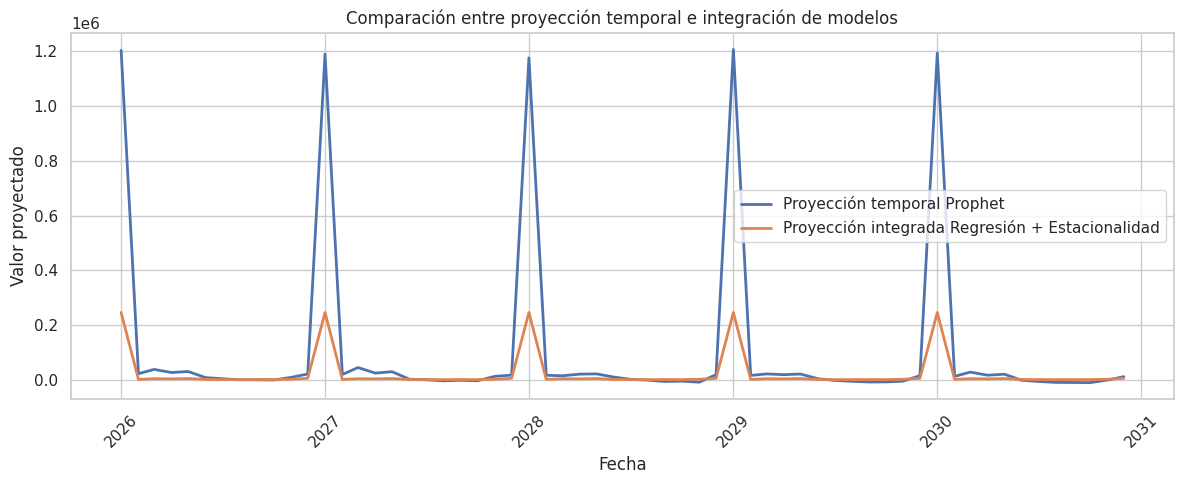

In [56]:
#Gráficamos de comparación entre la proyección temporal y la integración agregada
plt.figure(figsize=(12, 5))

plt.plot(
    comparacion_integrada["fecha"],
    comparacion_integrada["recaudacion_proyectada"],
    label="Proyección temporal Prophet",
    linewidth=2
)

plt.plot(
    comparacion_integrada["fecha"],
    comparacion_integrada["recaudacion_integrada"],
    label="Proyección integrada Regresión + Estacionalidad",
    linewidth=2
)

plt.title("Comparación entre proyección temporal e integración de modelos")
plt.xlabel("Fecha")
plt.ylabel("Valor proyectado")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_22_integracion_modelos_predictivos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
#Comparamos entre proyección temporal e integración agregada
comparacion_integrada = proyeccion_temporal.merge(
    integracion_mensual[["fecha", "recaudacion_integrada", "factor_estacional"]],
    on="fecha",
    how="left"
)

comparacion_integrada["diferencia_temporal_vs_integrada"] = (
    comparacion_integrada["recaudacion_proyectada"] -
    comparacion_integrada["recaudacion_integrada"]
)

comparacion_integrada.to_csv(
    f"{OUTPUT_DIR}/comparacion_proyeccion_temporal_integrada.csv",
    index=False
)

comparacion_integrada.head()

,fecha,recaudacion_proyectada,anio,mes_num,recaudacion_integrada,factor_estacional,diferencia_temporal_vs_integrada
0,2026-01-01,1.203183e+06,2026,1,245867.994747,0.903317,957315.432179
1,2026-02-01,2.234236e+04,2026,2,1529.605649,0.005620,20812.758206
2,2026-03-01,3.804442e+04,2026,3,4110.574803,0.015102,33933.843622
3,2026-04-01,2.663810e+04,2026,4,3529.382093,0.012967,23108.715681
4,2026-05-01,3.035734e+04,2026,5,4696.806973,0.017256,25660.529993


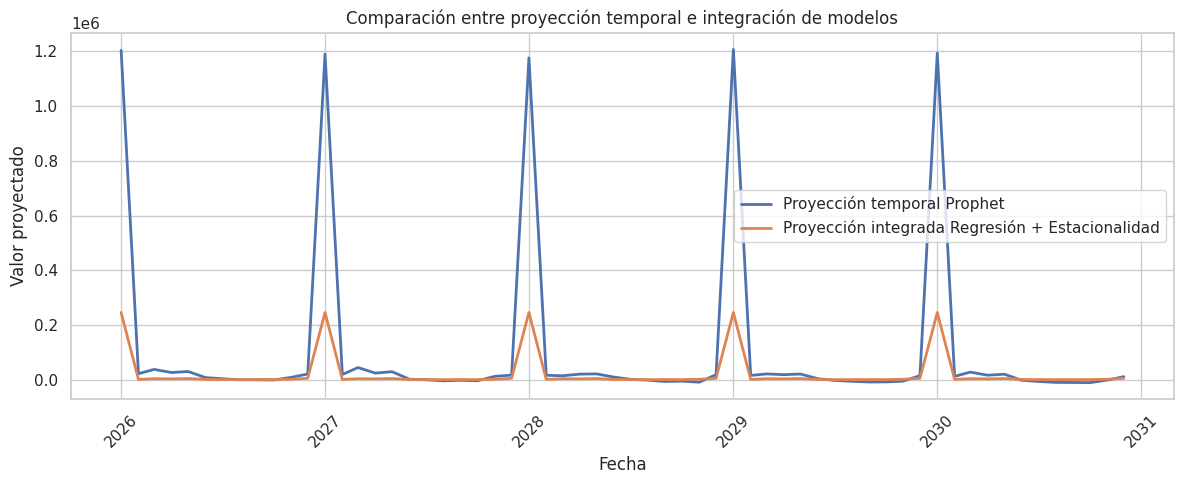

In [58]:
#Gráfico de comparación entre proyección temporal e integración
plt.figure(figsize=(12, 5))

plt.plot(
    comparacion_integrada["fecha"],
    comparacion_integrada["recaudacion_proyectada"],
    label="Proyección temporal Prophet",
    linewidth=2
)

plt.plot(
    comparacion_integrada["fecha"],
    comparacion_integrada["recaudacion_integrada"],
    label="Proyección integrada Regresión + Estacionalidad",
    linewidth=2
)

plt.title("Comparación entre proyección temporal e integración de modelos")
plt.xlabel("Fecha")
plt.ylabel("Valor proyectado")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/ilustracion_22_integracion_modelos_predictivos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
#Análisis de sensibilidad de escenarios financieros
resumen_escenarios_anual = pd.read_csv(
    f"{OUTPUT_DIR}/tabla_12_escenarios_financieros_anuales.csv"
)

resumen_escenarios_anual["brecha_moderado_vs_pesimista"] = (
    resumen_escenarios_anual["escenario_moderado_70"] -
    resumen_escenarios_anual["escenario_pesimista_30"]
)

resumen_escenarios_anual["brecha_optimo_vs_moderado"] = (
    resumen_escenarios_anual["escenario_optimo_100"] -
    resumen_escenarios_anual["escenario_moderado_70"]
)

resumen_escenarios_anual["brecha_optimo_vs_pesimista"] = (
    resumen_escenarios_anual["escenario_optimo_100"] -
    resumen_escenarios_anual["escenario_pesimista_30"]
)

resumen_escenarios_anual.to_csv(
    f"{OUTPUT_DIR}/tabla_13_sensibilidad_escenarios_financieros.csv",
    index=False
)

resumen_escenarios_anual

,anio,escenario_pesimista_30,escenario_moderado_70,escenario_optimo_100,brecha_moderado_vs_pesimista,brecha_optimo_vs_moderado,brecha_optimo_vs_pesimista
0,2026,408773.879036,953805.717751,1.362580e+06,545031.838715,408773.879036,953805.717751
1,2027,399569.845764,932329.640115,1.331899e+06,532759.794352,399569.845764,932329.640115
2,2028,377874.523599,881707.221732,1.259582e+06,503832.698132,377874.523599,881707.221732
3,2029,382690.991470,892945.646764,1.275637e+06,510254.655294,382690.991470,892945.646764
4,2030,373523.131421,871553.973317,1.245077e+06,498030.841895,373523.131421,871553.973317


In [60]:
#Análisis de sensibilidad entre escenarios
sensibilidad_escenarios = resumen_escenarios_anual.copy()

sensibilidad_escenarios["brecha_moderado_vs_pesimista"] = (
    sensibilidad_escenarios["escenario_moderado_70"] -
    sensibilidad_escenarios["escenario_pesimista_30"]
)

sensibilidad_escenarios["brecha_optimo_vs_moderado"] = (
    sensibilidad_escenarios["escenario_optimo_100"] -
    sensibilidad_escenarios["escenario_moderado_70"]
)

sensibilidad_escenarios["brecha_optimo_vs_pesimista"] = (
    sensibilidad_escenarios["escenario_optimo_100"] -
    sensibilidad_escenarios["escenario_pesimista_30"]
)

sensibilidad_escenarios.to_csv(
    f"{OUTPUT_DIR}/tabla_14_sensibilidad_escenarios_financieros.csv",
    index=False
)

sensibilidad_escenarios

,anio,escenario_pesimista_30,escenario_moderado_70,escenario_optimo_100,brecha_moderado_vs_pesimista,brecha_optimo_vs_moderado,brecha_optimo_vs_pesimista
0,2026,408773.879036,953805.717751,1.362580e+06,545031.838715,408773.879036,953805.717751
1,2027,399569.845764,932329.640115,1.331899e+06,532759.794352,399569.845764,932329.640115
2,2028,377874.523599,881707.221732,1.259582e+06,503832.698132,377874.523599,881707.221732
3,2029,382690.991470,892945.646764,1.275637e+06,510254.655294,382690.991470,892945.646764
4,2030,373523.131421,871553.973317,1.245077e+06,498030.841895,373523.131421,871553.973317


In [61]:
#Análisis de sostenibilidad financiera
presupuesto_gad = 10000000  #Valor referencial. Cambiar por el presupuesto real.

sostenibilidad_financiera = resumen_escenarios_anual.copy()

sostenibilidad_financiera["cobertura_pesimista_30"] = (
    sostenibilidad_financiera["escenario_pesimista_30"] / presupuesto_gad
) * 100

sostenibilidad_financiera["cobertura_moderado_70"] = (
    sostenibilidad_financiera["escenario_moderado_70"] / presupuesto_gad
) * 100

sostenibilidad_financiera["cobertura_optimo_100"] = (
    sostenibilidad_financiera["escenario_optimo_100"] / presupuesto_gad
) * 100

sostenibilidad_financiera.to_csv(
    f"{OUTPUT_DIR}/tabla_13_sostenibilidad_financiera.csv",
    index=False
)

sostenibilidad_financiera

,anio,escenario_pesimista_30,escenario_moderado_70,escenario_optimo_100,brecha_moderado_vs_pesimista,brecha_optimo_vs_moderado,brecha_optimo_vs_pesimista,cobertura_pesimista_30,cobertura_moderado_70,cobertura_optimo_100
0,2026,408773.879036,953805.717751,1.362580e+06,545031.838715,408773.879036,953805.717751,4.087739,9.538057,13.625796
1,2027,399569.845764,932329.640115,1.331899e+06,532759.794352,399569.845764,932329.640115,3.995698,9.323296,13.318995
2,2028,377874.523599,881707.221732,1.259582e+06,503832.698132,377874.523599,881707.221732,3.778745,8.817072,12.595817
3,2029,382690.991470,892945.646764,1.275637e+06,510254.655294,382690.991470,892945.646764,3.826910,8.929456,12.756366
4,2030,373523.131421,871553.973317,1.245077e+06,498030.841895,373523.131421,871553.973317,3.735231,8.715540,12.450771


Se puede eemplazar este valor por el presupuesto oficial anual del GAD Municipal cuando se disponga del dato validado en la memoria o en la fuente institucional.



In [62]:
#Análisis de sensibilidad entre escenarios
sensibilidad_escenarios = resumen_escenarios_anual.copy()

sensibilidad_escenarios["brecha_moderado_vs_pesimista"] = (
    sensibilidad_escenarios["escenario_moderado_70"] -
    sensibilidad_escenarios["escenario_pesimista_30"]
)

sensibilidad_escenarios["brecha_optimo_vs_moderado"] = (
    sensibilidad_escenarios["escenario_optimo_100"] -
    sensibilidad_escenarios["escenario_moderado_70"]
)

sensibilidad_escenarios["brecha_optimo_vs_pesimista"] = (
    sensibilidad_escenarios["escenario_optimo_100"] -
    sensibilidad_escenarios["escenario_pesimista_30"]
)

sensibilidad_escenarios.to_csv(
    f"{OUTPUT_DIR}/tabla_14_sensibilidad_escenarios_financieros.csv",
    index=False
)

sensibilidad_escenarios

,anio,escenario_pesimista_30,escenario_moderado_70,escenario_optimo_100,brecha_moderado_vs_pesimista,brecha_optimo_vs_moderado,brecha_optimo_vs_pesimista
0,2026,408773.879036,953805.717751,1.362580e+06,545031.838715,408773.879036,953805.717751
1,2027,399569.845764,932329.640115,1.331899e+06,532759.794352,399569.845764,932329.640115
2,2028,377874.523599,881707.221732,1.259582e+06,503832.698132,377874.523599,881707.221732
3,2029,382690.991470,892945.646764,1.275637e+06,510254.655294,382690.991470,892945.646764
4,2030,373523.131421,871553.973317,1.245077e+06,498030.841895,373523.131421,871553.973317


In [63]:
presupuesto_gad = 10000000

In [64]:
#Preparación de archivo maestro para Power BI
escenarios["mes_num"] = escenarios["fecha"].dt.month

master_data_viz = escenarios.merge(
    estacionalidad_mensual[["mes_num", "mes_nombre", "factor_estacional"]],
    on="mes_num",
    how="left"
)

master_data_viz = master_data_viz.merge(
    comparacion_integrada[[
        "fecha",
        "recaudacion_proyectada",
        "recaudacion_integrada",
        "diferencia_temporal_vs_integrada"
    ]],
    on="fecha",
    how="left"
)

master_data_viz = master_data_viz[
    [
        "fecha",
        "anio",
        "mes_num",
        "mes_nombre",
        "factor_estacional",
        "proyeccion_base",
        "recaudacion_proyectada",
        "recaudacion_integrada",
        "diferencia_temporal_vs_integrada",
        "escenario_pesimista_30",
        "escenario_moderado_70",
        "escenario_optimo_100"
    ]
]

master_data_viz.to_csv(
    f"{OUTPUT_DIR}/master_data_viz.csv",
    index=False
)

master_data_viz.head()

,fecha,anio,mes_num,mes_nombre,factor_estacional,proyeccion_base,recaudacion_proyectada,recaudacion_integrada,diferencia_temporal_vs_integrada,escenario_pesimista_30,escenario_moderado_70,escenario_optimo_100
0,2026-01-01,2026,1,January,0.903317,1.203183e+06,1.203183e+06,245867.994747,957315.432179,360955.028078,842228.398848,1.203183e+06
1,2026-02-01,2026,2,February,0.005620,2.234236e+04,2.234236e+04,1529.605649,20812.758206,6702.709156,15639.654698,2.234236e+04
2,2026-03-01,2026,3,March,0.015102,3.804442e+04,3.804442e+04,4110.574803,33933.843622,11413.325527,26631.092897,3.804442e+04
3,2026-04-01,2026,4,April,0.012967,2.663810e+04,2.663810e+04,3529.382093,23108.715681,7991.429332,18646.668442,2.663810e+04
4,2026-05-01,2026,5,May,0.017256,3.035734e+04,3.035734e+04,4696.806973,25660.529993,9107.201090,21250.135876,3.035734e+04


In [65]:
import os
archivos_finales = [
    "comparacion_proyeccion_temporal_integrada.csv",
    "ilustracion_22_integracion_modelos_predictivos.png",
    "tabla_13_sostenibilidad_financiera.csv",
    "tabla_14_sensibilidad_escenarios_financieros.csv",
    "master_data_viz.csv"
]

for archivo in archivos_finales:
    ruta_archivo = f"{OUTPUT_DIR}/{archivo}"
    print(archivo, "OK" if os.path.exists(ruta_archivo) else "FALTA")

comparacion_proyeccion_temporal_integrada.csv OK
ilustracion_22_integracion_modelos_predictivos.png OK
tabla_13_sostenibilidad_financiera.csv OK
tabla_14_sensibilidad_escenarios_financieros.csv OK
master_data_viz.csv OK
